In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from seq_encode.smiles import smiles_coder
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
from rdkit.Chem import DataStructs


# load data
with open("/home/hwx/python_project/test/Boron/V3/processed_data/additives.json", "r") as f:
    data = json.load(f)

smiles_strings = [values['smiles'] for values in data.values()]
coder = smiles_coder()
coder.fit(smiles_strings)

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

fp_representation_list = []
onehot_representation_list = []
for key, values in data.items():
    smile = values['smiles']
    mol = Chem.MolFromSmiles(smile)
    
    # fingerprint
    fp = morgan_gen.GetFingerprint(mol)  
    output_fp = np.zeros((1,))
    DataStructs.ConvertToNumpyArray(fp, output_fp)

    # one-hot
    smile = [smile]
    output_onehot = coder.transform(smile)

    fp_representation_list.append(output_fp)
    onehot_representation_list.append(output_onehot)


# Convert lists to numpy arrays
fp_array = np.array(fp_representation_list)
onehot_array = np.array(onehot_representation_list)
print(f"Fingerprint array shape: {fp_array.shape}")
print(f"One-hot array shape: {onehot_array.shape}")





100%|██████████| 1/1 [00:00<00:00, 10180.35it/s]


Fingerprint array shape: (126, 1024)
One-hot array shape: (126, 1, 150, 30)


Training samples: 126


Unsupervised learning trials...:   0%|          | 0/10 [00:00<?, ?it/s]

Unsupervised learning trials...:  10%|█         | 1/10 [00:06<00:59,  6.62s/it]

Trial 1/10 | Best silhouette = 0.287999


Unsupervised learning trials...:  20%|██        | 2/10 [00:11<00:46,  5.84s/it]

...

Trial 8/10 | Best silhouette = 0.290411


Unsupervised learning trials...:  90%|█████████ | 9/10 [00:51<00:06,  6.41s/it]

Trial 9/10 | Best silhouette = 0.281451


Unsupervised learning trials...: 100%|██████████| 10/10 [00:58<00:00,  5.90s/it]
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Trial 10/10 | Best silhouette = 0.285028

========== FP/SMILES USL Silhouette Summary ==========
Number of trials: 10
Best trial: 5
Best silhouette score: 0.295734
Mean silhouette score: 0.274545
Std silhouette score: 0.016068
Silhouette score: 0.274545 ± 0.016068
Time cost: 2.996922 ± 1.842590
All trial scores:
[0.2879986  0.24626938 0.2626155  0.26160485 0.29573378 0.27292526
 0.26141647 0.29041082 0.2814509  0.28502777]

Saved summary to: USL_silhouette_FP_SMILES_mean_std.txt


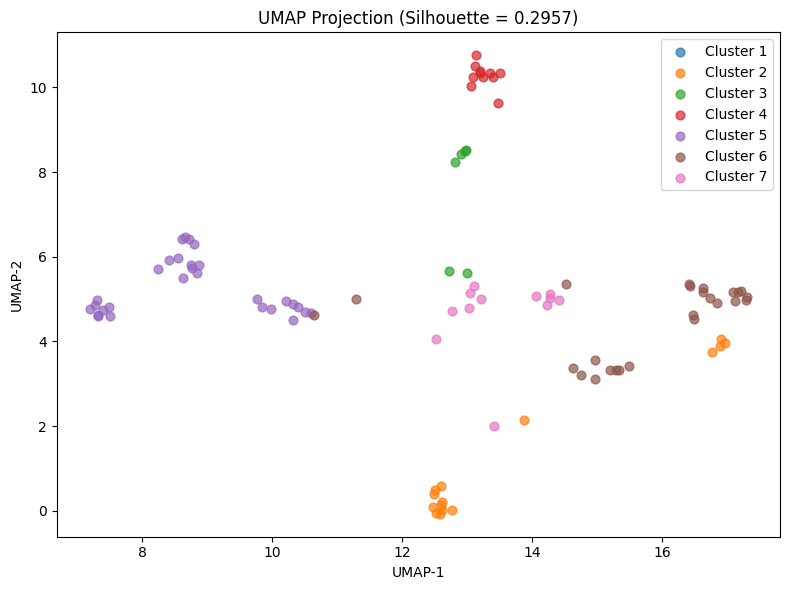

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import time
import numpy as np
import matplotlib.pyplot as plt
import umap
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, emb_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, emb_dim)
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)


def info_nce_loss(z1, z2, temperature=0.5):
    """
    z1, z2: shape [N, d]
    """
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    N = z1.size(0)

    sim_matrix = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(N).to(z1.device)
    loss = F.cross_entropy(sim_matrix, labels)

    return loss


def augment(x, drop_prob=0.1):
    mask = np.random.rand(*x.shape) > drop_prob
    return x * mask


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def unsupervised_training(pos_train_samples, pos_test_samples):
    # Unsupervised training
    model = Encoder(input_dim=pos_train_samples.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)

    unsuper_train_loss = []
    silhouette_scores = 0
    best_model = None
    best_embeddings = None
    best_labels = None
    start_time = time.time()
    for epoch in tqdm(range(1, 501), desc='Training the representation FP/SMILES ...'):
        model.train()

        # data augmentation for contrastive learning
        x1 = torch.tensor(augment(pos_train_samples), dtype=torch.float32).to(device)
        x2 = torch.tensor(augment(pos_train_samples), dtype=torch.float32).to(device)

        z1 = model(x1)
        z2 = model(x2)

        loss = info_nce_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        unsuper_train_loss.append(loss.item())

        # =========================
        # Evaluate embeddings
        # =========================
        model.eval()

        all_embeddings = []
        with torch.no_grad():
            x = torch.tensor(pos_train_samples, dtype=torch.float32).to(device)
            out = model(x)
            all_embeddings.append(out.cpu())

        all_embeddings = F.normalize(torch.cat(all_embeddings), dim=-1).numpy()

        # hierarchical cluster 
        Z = linkage(all_embeddings, method='average', metric='cosine') 
        labels = fcluster(Z, t=7, criterion='maxclust') 
        sil = silhouette_score(all_embeddings, labels, metric='cosine')

        # # KMeans clustering
        # kmeans = KMeans(n_clusters=7, random_state=42, n_init=20)
        # labels = kmeans.fit_predict(all_embeddings)
        # sil = silhouette_score(all_embeddings, labels, metric='cosine')

        end_time = time.time()
        time_cost_trial = end_time - start_time
        trial_time_costs.append(time_cost_trial)

        if sil > silhouette_scores:
            silhouette_scores = sil
            best_embeddings = all_embeddings
            best_labels = labels
            best_model = model.state_dict()

    return best_embeddings, best_labels, silhouette_scores, best_model


# =========================
# Main training
# =========================
print('Training samples:', len(onehot_array))

onehot_array = onehot_array.reshape(onehot_array.shape[0], -1)

best_model_global = None
best_label = None
best_sil_score = -1
best_embeddings_global = None
best_trial = None

# 保存每个 trial 的 best silhouette
trial_silhouette_scores = []
trial_time_costs = []

num_trials = 10

for trial in tqdm(range(num_trials), desc='Unsupervised learning trials...'):
    best_embeddings, best_labels, silhouette_score_trial, best_model = unsupervised_training(
        fp_array, []
    )

    trial_silhouette_scores.append(silhouette_score_trial)

    print(
        f'Trial {trial + 1}/{num_trials} | '
        f'Best silhouette = {silhouette_score_trial:.6f}'
    )

    if silhouette_score_trial > best_sil_score:
        best_sil_score = silhouette_score_trial
        best_label = best_labels
        best_model_global = best_model
        best_embeddings_global = best_embeddings
        best_trial = trial + 1


# =========================
# Mean ± std
# =========================
trial_silhouette_scores = np.array(trial_silhouette_scores)
trial_time_costs = np.array(trial_time_costs)

sil_mean = trial_silhouette_scores.mean()
sil_std = trial_silhouette_scores.std(ddof=1)

time_mean = trial_time_costs.mean()
time_std = trial_time_costs.std(ddof=1)

print('\n========== FP/SMILES USL Silhouette Summary ==========')
print(f'Number of trials: {num_trials}')
print(f'Best trial: {best_trial}')
print(f'Best silhouette score: {best_sil_score:.6f}')
print(f'Mean silhouette score: {sil_mean:.6f}')
print(f'Std silhouette score: {sil_std:.6f}')
print(f'Silhouette score: {sil_mean:.6f} ± {sil_std:.6f}')
print(f'Time cost: {time_mean:.6f} ± {time_std:.6f}')
print('All trial scores:')
print(trial_silhouette_scores)
print('======================================================\n')


# =========================
# Save summary to txt
# =========================
save_name = 'USL_silhouette_FP_SMILES_mean_std.txt'

with open(save_name, 'w', encoding='utf-8') as f:
    f.write('========== FP/SMILES USL Silhouette Summary ==========\n')
    f.write(f'Number of trials: {num_trials}\n')
    f.write(f'Best trial: {best_trial}\n')
    f.write(f'Best silhouette score: {best_sil_score:.6f}\n')
    f.write(f'Mean silhouette score: {sil_mean:.6f}\n')
    f.write(f'Std silhouette score: {sil_std:.6f}\n')
    f.write(f'Silhouette score: {sil_mean:.6f} ± {sil_std:.6f}\n')
    f.write('All trial scores:\n')
    f.write(', '.join([f'{x:.6f}' for x in trial_silhouette_scores]))
    f.write('\n======================================================\n')

print(f'Saved summary to: {save_name}')


# =========================
# UMAP visualization using best trial
# =========================
sil = silhouette_score(best_embeddings_global, best_label, metric='cosine')

reducer = umap.UMAP(random_state=42, metric='cosine')
umap_embeds = reducer.fit_transform(best_embeddings_global)

plt.figure(figsize=(8, 6))
label_num = len(set(best_label))

# 注意：KMeans 的 label 是从 0 开始，不是从 1 开始
for i in range(label_num):
    plt.scatter(
        umap_embeds[best_label == i, 0],
        umap_embeds[best_label == i, 1],
        s=40,
        label=f"Cluster {i + 1}",
        alpha=0.7
    )

plt.legend()
plt.title(f"UMAP Projection (Silhouette = {sil:.4f})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, Dropout, Sequential, ReLU, MultiheadAttention, LayerNorm, BatchNorm1d
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import (
    GraphNorm,
    GCNConv,
    GINEConv,
    GINConv,
    GATConv,
    global_mean_pool
)


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return self.mlp(x)


class Cluster_GINE(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GINE, self).__init__()

        nn1 = Sequential(Linear(num_node_features, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINEConv(nn1, edge_dim=num_edge_features)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINEConv(nn2, edge_dim=num_edge_features)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINEConv(nn3, edge_dim=num_edge_features)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch): 
        x = self.conv1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GCN, self).__init__()

        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.norm2 = GraphNorm(hidden_channels)

        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GCN 不使用 edge_attr
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GIN(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout):
        super(Cluster_GIN, self).__init__()

        nn1 = Sequential(
            Linear(num_node_features, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv1 = GINConv(nn1)
        self.norm1 = GraphNorm(hidden_channels)

        nn2 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv2 = GINConv(nn2)
        self.norm2 = GraphNorm(hidden_channels)

        nn3 = Sequential(
            Linear(hidden_channels, hidden_channels),
            ReLU(),
            Linear(hidden_channels, hidden_channels)
        )
        self.conv3 = GINConv(nn3)
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GIN 不使用 edge_attr
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

class Cluster_GAT(torch.nn.Module):
    def __init__(self, num_node_features, num_edge_features, hidden_channels, num_classes, dropout, heads=4):
        super(Cluster_GAT, self).__init__()

        self.conv1 = GATConv(
            in_channels=num_node_features,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm1 = GraphNorm(hidden_channels)

        self.conv2 = GATConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm2 = GraphNorm(hidden_channels)

        self.conv3 = GATConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            heads=heads,
            concat=False,
            dropout=dropout,
            edge_dim=num_edge_features
        )
        self.norm3 = GraphNorm(hidden_channels)

        self.dropout = Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # GAT 可以使用 edge_attr
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_attr=edge_attr)
        x = self.norm3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)

        return x

In [7]:
import pickle

# data preparation
with open('/home/hwx/python_project/test/Boron/data/all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)

positive_samples = all_data[:126] # number of positive samples

Training samples: 126


Unsupervised learning trials...:   0%|          | 0/10 [00:00<?, ?it/s]

Unsupervised learning trials...:  10%|█         | 1/10 [00:21<03:13, 21.53s/it]

Trial 1/10 | Best silhouette = 0.784716


Unsupervised learning trials...:  20%|██        | 2/10 [00:43<02:52, 21.60s/it]

...

Trial 8/10 | Best silhouette = 0.779226


Unsupervised learning trials...:  90%|█████████ | 9/10 [02:59<00:18, 18.54s/it]

Trial 9/10 | Best silhouette = 0.824345


Unsupervised learning trials...: 100%|██████████| 10/10 [03:17<00:00, 19.75s/it]
/home/hwx/envs/boron/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Trial 10/10 | Best silhouette = 0.740224

========== USL Silhouette Summary ==========
Model backbone: GAT
Number of trials: 10
Best trial: 9
Best silhouette score: 0.824345
Silhouette score: 0.761661 ± 0.030362
All trial scores:
[0.7847164  0.74412864 0.749649   0.7164156  0.7779916  0.7462064
 0.7537033  0.77922606 0.8243446  0.74022377]



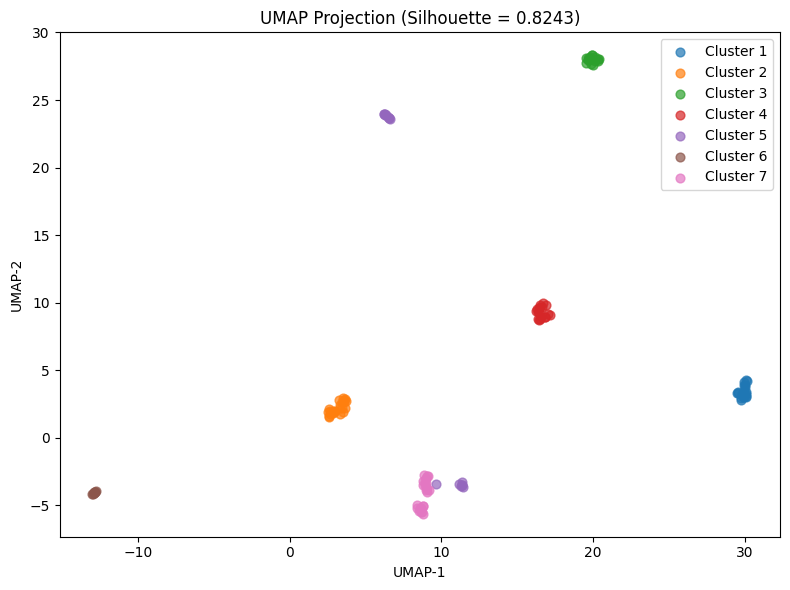

In [ ]:
import torch
import random
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import pickle
import argparse
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import pairwise_distances
import umap
import time

# graph augmentation configs
parser = argparse.ArgumentParser(description="Train the model")
parser.add_argument('--aug_types', type=str, default='all', help='augmentation types')
parser.add_argument('--shuffle_ratio', type=float, default=0.2, help='shuffle ratio')
parser.add_argument('--node_drop_ratio', type=float, default=0.2, help='node drop ratio')
parser.add_argument('--noise_ratio', type=float, default=0.2, help='noise_ratio')
parser.add_argument('--noise_std', type=float, default=0.1, help='noise_std')
parser.add_argument('--edge_drop_ratio', type=float, default=0.1, help='edge drop ratio')
parser.add_argument('--edge_add_ratio', type=float, default=0.05, help='edge add ratio')
parser.add_argument('--alpha', type=float, default=0.15, help='PPR alpha')
parser.add_argument('--PPR_drop_ratio', type=float, default=0.2, help='PPR_drop_ratio')
parser.add_argument('--PPR_add_ratio', type=float, default=0.2, help='PPR_add_ratio')
parser.add_argument('--K', type=int, default=10, help='PPR K')
parser.add_argument('--random_state', type=int, default=42, help='data split random seed')
parser.add_argument('--test_size', type=float, default=0.2, help='test set size')

parser.add_argument('--analysis', type=bool, default=False, help='Wether to print the summary of the dataset')
parser.add_argument('--usl_batch_size', type=int, default=256, help='Batch size for training')
parser.add_argument('--num_classes', type=int, default=2, help='Number of classes')
parser.add_argument('--usl_learning_rate', type=float, default=0.0005, help='Learning rate')
parser.add_argument('--usl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--epoch', type=int, default=500, help='Number of training epochs')
parser.add_argument('--dropout', type=float, default=0.5, help='Value of dropout')
parser.add_argument('--training_types', type=str, default='Unsupervised learning', help='training_types')
parser.add_argument('--models', type=str, default='GINE', help='Training models')
parser.add_argument('--embed_dim', type=int, default=256, help='Embedding dimension of attention')
parser.add_argument('--num_heads', type=int, default=4, help='Number of heads for attention')
parser.add_argument('--desp_dim', type=int, default=217, help='Number of descriptors')
parser.add_argument('--retrain_usl', type=bool, default=False, help='retrain the usl models')
parser.add_argument('--usl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
parser.add_argument('--save_path', type=str, default='checkpoints_top35', help='')

parser.add_argument('--max_cluster', type=int, default=10, help='max cluster number')
parser.add_argument('--temperature', type=float, default=0.1, help='temperature coefficient for prototypes')
parser.add_argument('--proto_epoch', type=int, default=300, help='Number of training epochs')
parser.add_argument('--r', type=int, default=10000, help='number of randomly select neg prototypes')
parser.add_argument('--proto_training_types', type=str, default='Prototype contrastive learning', help='training_types')
parser.add_argument('--proto_models', type=str, default='GINE', help='model name for PCL')
parser.add_argument('--pcl_hidden_channels', type=int, default=256, help='Number of hidden channels')
parser.add_argument('--pcl_learning_rate', type=float, default=0.00001, help='Learning rate')
parser.add_argument('--pcl_batch_size', type=int, default=1024, help='Batch size for training')
parser.add_argument('--threshold', type=float, default=0.3, help='threshold')
parser.add_argument('--topk', type=int, default=35, help='top k samples for each prototype')
parser.add_argument('--pcl_trials', type=int, default=10, help='Number of trials for unsupervised learning')
args = parser.parse_args(args=[])

def filter_cluster_outliers(embeddings, cluster_labels, alpha=1.5):
    filtered_embeddings = []
    filtered_labels = []
    filtered_indices = []

    unique_clusters = np.unique(cluster_labels)

    for cluster_id in unique_clusters:
        idx = np.where(cluster_labels == cluster_id)[0]
        cluster_emb = embeddings[idx]

        if len(cluster_emb) < 2:
            continue

        centroid = np.mean(cluster_emb, axis=0)
        distances = np.linalg.norm(cluster_emb - centroid, axis=1)

        # threshold = mean + α * std
        d_mean = distances.mean()
        d_std = distances.std()
        threshold = d_mean + alpha * d_std

        mask = distances <= threshold

        filtered_embeddings.append(cluster_emb[mask])
        filtered_labels.append(cluster_labels[idx][mask])
        filtered_indices.append(idx[mask])

    filtered_embeddings = np.vstack(filtered_embeddings)
    filtered_labels = np.concatenate(filtered_labels)
    filtered_indices = np.concatenate(filtered_indices)
    return filtered_embeddings, filtered_labels, filtered_indices

def try_multiple_cluster_combinations(Z, all_embeddings, pos_additives_names, args):
    possible_clusters = range(3, args.max_cluster+1)
    best_score = -1
    best_k = None
    best_labels = None
    best_embeddings = None
    best_names = None
    best_Z = None

    for k in possible_clusters:
        cluster_labels = fcluster(Z, t=k, criterion='maxclust')

        # filter the outliers in each cluster
        filtered_embeddings, filtered_labels, filtered_indices = filter_cluster_outliers(all_embeddings, cluster_labels)

        try:
            Z_filt = linkage(filtered_embeddings, method='average', metric='cosine')
            score = silhouette_score(filtered_embeddings, filtered_labels, metric='cosine')
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = filtered_labels
                best_embeddings = filtered_embeddings
                if args.retrain_usl:
                    best_names = None
                else:
                    best_names = np.array(pos_additives_names)[filtered_indices].tolist()
                best_Z = Z_filt
        except Exception as e:
            print(f"k={k} failed: {e}")

    # print(f"\n✅ best cluster number: {best_k}, average silhouette score: {best_score:.4f}")

    return best_k, best_labels, best_embeddings, best_names, best_Z

def perturb_edges(data, device, perturb_ratio=0.1):
    edge_index = data.edge_index.clone()
    num_edges = edge_index.size(1)
    num_nodes = data.x.size(0)

    num_delete = int(num_edges * perturb_ratio / 2)
    mask = torch.ones(num_edges, dtype=torch.bool)
    del_indices = random.sample(range(num_edges), num_delete)
    mask[del_indices] = False
    edge_index = edge_index[:, mask]

    num_add = num_delete
    new_edges = torch.randint(0, num_nodes, (2, num_add), device=device)
    edge_index = torch.cat([edge_index, new_edges], dim=1)

    data.edge_index = edge_index
    return data


def info_nce_loss(z1, z2, temperature=0.5):
    """
    z1, z2: shape [N, d]
    """
    z1 = F.normalize(z1, dim=-1)
    z2 = F.normalize(z2, dim=-1)
    N = z1.size(0)
    
    sim_matrix = torch.mm(z1, z2.t()) / temperature
    labels = torch.arange(N).to(z1.device)
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


def unsupervised_training(pos_train_samples, pos_test_samples):
    # Unsupervised training
    # train a GNN model to represent all positive training data and get the prototypes
    pos_train_samples = pos_train_samples + pos_test_samples
    train_loader = DataLoader(pos_train_samples, batch_size=args.usl_batch_size, shuffle=True)
    if args.models == 'GINE':
        model = Cluster_GINE(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)
    elif args.models == 'GCN':
        model = Cluster_GCN(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)
    elif args.models == 'GIN':
        model = Cluster_GIN(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)
    elif args.models == 'GAT':
        model = Cluster_GAT(num_node_features=pos_train_samples[0].x.shape[1], num_edge_features=pos_train_samples[0].edge_attr.shape[1], 
            hidden_channels=args.usl_hidden_channels,
            num_classes=args.num_classes, dropout=args.dropout).to(device)

    projection_head1 = ProjectionHead(in_dim=args.usl_hidden_channels).to(device)
    projection_head2 = ProjectionHead(in_dim=args.usl_hidden_channels).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.usl_learning_rate, weight_decay=5e-4)
    
    unsuper_train_loss = []
    silhouette_scores = 0
    best_model = None
    best_embeddings = None
    best_labels = None
    start_time = time.time()
    for epoch in tqdm(range(1, args.epoch + 1), desc='Training the representation GNN...'):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)

            # graph augmentation: for constractive learning 
            data_aug1 = data.clone() 
            data_aug2 = perturb_edges(data.clone(), device) 
            
            out1 = model(data_aug1.x, data_aug1.edge_index, data_aug1.edge_attr, data_aug1.batch)
            out2 = model(data_aug2.x, data_aug2.edge_index, data_aug2.edge_attr, data_aug2.batch) 
            pro_out1 = projection_head1(out1) 
            pro_out2 = projection_head2(out2)
            
            loss = info_nce_loss(pro_out1, pro_out2)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        unsuper_train_loss.append(avg_loss)

        model.eval()
        eval_loader = DataLoader(pos_train_samples, batch_size=args.usl_batch_size, shuffle=False)
        all_embeddings = []
        pos_additives_names = []
        with torch.no_grad():
            for data in eval_loader:
                data = data.to(device)
                pos_additives_names += data.id
                out = model(data.x, data.edge_index, data.edge_attr, data.batch)
                all_embeddings.append(out.cpu())

        all_embeddings = F.normalize(torch.cat(all_embeddings), dim=-1).numpy()

        # # hierarchical cluster
        # Z = linkage(all_embeddings, method='average', metric='cosine')
        # labels = fcluster(Z, t=7, criterion='maxclust')
        # sil = silhouette_score(all_embeddings, labels, metric='cosine')

        # KMeans clustering
        kmeans = KMeans(n_clusters=7, random_state=42, n_init=20)
        labels = kmeans.fit_predict(all_embeddings)

        end_time = time.time()
        time_cost_trial = end_time - start_time
        trial_time_costs.append(time_cost_trial)
        
        sil = silhouette_score(all_embeddings, labels, metric='cosine')

        if sil > silhouette_scores:
            silhouette_scores = sil
            best_embeddings = all_embeddings
            best_labels = labels
            best_model = model.state_dict()
    
    return best_embeddings, best_labels, silhouette_scores, best_model

print('Training samples:', len(positive_samples))

best_model_global = None
best_label = None
best_sil_score = -1
best_embeddings_global = None
best_trial = None

# =========================
# Store silhouette scores of all trials
# =========================
trial_silhouette_scores = []
trial_time_costs = []

for trial in tqdm(range(args.usl_trials), desc=f'Unsupervised learning trials...'):
    best_embeddings, best_labels, silhouette_score_trial, best_model = unsupervised_training(
        positive_samples, []
    )

    # 保存当前 trial 的 best silhouette
    trial_silhouette_scores.append(silhouette_score_trial)

    print(
        f'Trial {trial + 1}/{args.usl_trials} | '
        f'Best silhouette = {silhouette_score_trial:.6f}'
    )

    # 仍然保留最高分的模型，用于后续 UMAP 可视化
    if silhouette_score_trial > best_sil_score:
        best_sil_score = silhouette_score_trial
        best_label = best_labels
        best_model_global = best_model
        best_embeddings_global = best_embeddings
        best_trial = trial + 1


# =========================
# Calculate mean ± std
# =========================
trial_silhouette_scores = np.array(trial_silhouette_scores)
trial_time_costs = np.array(trial_time_costs)

sil_mean = trial_silhouette_scores.mean()
sil_std = trial_silhouette_scores.std(ddof=1)  # sample std，论文里更常用

time_mean = trial_time_costs.mean()
time_std = trial_time_costs.std(ddof=1)

print('\n========== USL Silhouette Summary ==========')
print(f'Model backbone: {args.models}')
print(f'Number of trials: {args.usl_trials}')
print(f'Best trial: {best_trial}')
print(f'Best silhouette score: {best_sil_score:.6f}')
print(f'Silhouette score: {sil_mean:.6f} ± {sil_std:.6f}')
print(f'Time cost: {time_mean:.6f} ± {time_std:.6f}')
print('All trial scores:')
print(trial_silhouette_scores)
print('============================================\n')


sil = silhouette_score(best_embeddings_global, best_label, metric='cosine')

reducer = umap.UMAP(random_state=42, metric='cosine')
umap_embeds = reducer.fit_transform(best_embeddings_global)

# 可视化不同簇在UMAP上的分布
plt.figure(figsize=(8,6))
label_num = len(set(best_label))
for i in range(1, label_num + 1):
    plt.scatter(umap_embeds[best_label==i, 0], umap_embeds[best_label==i, 1], s=40, label=f"Cluster {i}", alpha=0.7)
plt.legend()
plt.title(f"UMAP Projection (Silhouette = {sil:.4f})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()
# plt.savefig('/home/hwx/python_project/test/Boron/V3/plots/GNN_wo_aug.png', dpi=300)


In [13]:
import torch
from tqdm import tqdm
from torch_geometric.utils import subgraph
from torch_geometric.utils import to_networkx, from_networkx
import networkx as nx
import random
from torch_geometric.utils import to_dense_adj, dense_to_sparse
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

class Graph_Augmentation_Helper():
    def __init__(self, positive_samples, args):
        self.pos_samples = positive_samples
        self.aug_types = args.aug_types
        self.random_state = args.random_state
        self.test_size = args.test_size

        # augmentation configs
        self.shuffle_ratio = args.shuffle_ratio
        self.noise_ratio = args.noise_ratio
        self.noise_std = args.noise_std
        self.node_drop_ratio = args.node_drop_ratio
        self.edge_drop_ratio = args.edge_drop_ratio
        self.edge_add_ratio = args.edge_add_ratio
        self.alpha = args.alpha
        self.PPR_drop_ratio = args.PPR_drop_ratio
        self.PPR_add_ratio = args.PPR_add_ratio
        self.K = args.K


    def node_feature_shuffle(self, samples, shuffle_ratio):
        shuffled_samples = []
        for data in tqdm(samples, desc='Augment graph by node feature shuffling...'):
            num_features = data.x.size(1)
            num_shuffle = int(num_features * shuffle_ratio)

            perm = torch.randperm(num_features)
            shuffle_idx = perm[:num_shuffle]

            shuffled_x = data.x.clone()
            shuffled_x[:, shuffle_idx] = data.x[torch.randperm(data.x.size(0))][:, shuffle_idx]

            new_data = data.clone()
            new_data.x = shuffled_x
            new_data.id = int(str(data.id) + '000')
            shuffled_samples.append(new_data)

        return shuffled_samples
    

    def node_feature_noise_masking(self, samples, noise_ratio, noise_std):
        noise_masked_samples = []
        for data in tqdm(samples, desc='Augment graph by noise masking...'):
            x = data.x.clone()

            mask = torch.rand_like(x) < noise_ratio  

            noise = torch.randn_like(x) * noise_std
            x_noisy = x + noise * mask 

            new_data = data.clone()
            new_data.x = x_noisy
            new_data.id = int(str(data.id) + '001')
            noise_masked_samples.append(new_data)
        
        return noise_masked_samples


    def node_dropping(self, samples, drop_ratio=0.2):
        """

        """
        dropped_samples = []
        for data in tqdm(samples, desc='Augment graph by node dropping...'):
            num_nodes = data.n_nodes
            
            num_drop = max(1, int(num_nodes * drop_ratio))  # at less drop one node
            drop_nodes = torch.randperm(num_nodes)[:num_drop]
            
            keep_mask = torch.ones(num_nodes, dtype=torch.bool)
            keep_mask[drop_nodes] = False
            keep_nodes = keep_mask.nonzero(as_tuple=False).view(-1)
            
            edge_index, edge_attr = subgraph(
                subset=keep_nodes,
                edge_index=data.edge_index,
                edge_attr=data.edge_attr if hasattr(data, "edge_attr") else None,
                relabel_nodes=True, 
                num_nodes=num_nodes
            )
            
            new_data = data.clone()
            new_data.x = data.x[keep_nodes]
            new_data.edge_index = edge_index
            new_data.edge_attr = edge_attr
            new_data.n_nodes = keep_nodes.size(0)
            new_data.id = int(str(data.id) + '010')
            dropped_samples.append(new_data)
        
        return dropped_samples
    

    def edge_perturbation_weighted(self, samples, drop_ratio, add_ratio):
        """

        """
        edge_perturbation_weighted_samples = []
        for data in tqdm(samples, desc='Augment graph by edge perturbation weighting...'):
            num_nodes = data.x.size(0)
            G = to_networkx(data, to_undirected=True)
            nodes_list = range(num_nodes)
            center_node = random.choice(nodes_list)
             
            lengths = dict(nx.single_source_shortest_path_length(G, center_node))

            max_hop = max(lengths.values()) if lengths else 0
            default_hop = max_hop + 1
            
            deg = dict(G.degree())
            
            edge_list = list(G.edges())
            edge_weights = []
            for (u, v) in edge_list:

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                hop = min(hop_u, hop_v)

                d_u = deg[u]
                d_v = deg[v]
                d = max(d_u, d_v)

                w = (1.0 / (hop + 1)) * (d / (d + 1))
                edge_weights.append(w)
 
            weights = torch.tensor(edge_weights, dtype=torch.float)
            probs = weights / weights.sum()
            

            num_drop = max(1, int(len(edge_list) * drop_ratio))
            drop_idx = torch.multinomial(probs, num_drop, replacement=False).tolist()
            drop_edges = [edge_list[i] for i in drop_idx]
            for (u,v) in drop_edges:
                if G.has_edge(u,v):
                    G.remove_edge(u, v)

            num_add = int(len(edge_list) * add_ratio)

            node_pairs = []
            attempts = 0
            while len(node_pairs) < num_add and attempts < num_add * 10:
                u = random.randrange(num_nodes)
                v = random.randrange(num_nodes)
                if u==v or G.has_edge(u,v):
                    attempts += 1
                    continue

                hop_u = lengths.get(u, default_hop)
                hop_v = lengths.get(v, default_hop)
                if abs(hop_u - hop_v) > 0:  
                    G.add_edge(u, v)
                    node_pairs.append((u, v))
                attempts += 1
            

            new_edge_index = from_networkx(G)
            new_data = data.clone()
            new_data.x = data.x
            new_data.edge_index = new_edge_index.edge_index
            if hasattr(data, 'edge_attr'):
                new_data.edge_attr = torch.zeros((new_data.edge_index.size(1), data.edge_attr.size(1)))
            new_data.id = int(str(data.id) + '011')
            
            edge_perturbation_weighted_samples.append(new_data)

        return edge_perturbation_weighted_samples
    

    def personalized_pagerank_augmentation(self, samples, alpha, drop_ratio, add_ratio, K):
        """
        Personalized PageRank (PPR) based graph augmentation
        Args:
            data: PyG Data 对象
            alpha: teleport 概率（默认 0.15）
            drop_ratio: 删除边比例
            add_ratio: 添加边比例
        """
        PPR_samples = []

        for data in tqdm(samples, desc='Augment graph by personalized pagerank...'):
            num_nodes = data.num_nodes
            edge_index = data.edge_index

            # Step 1: 构建对称邻接矩阵
            A = to_dense_adj(edge_index, max_num_nodes=num_nodes).squeeze(0)
            A = (A + A.t()) / 2
            A.fill_diagonal_(0)

            # Step 2: 归一化邻接矩阵
            deg = A.sum(dim=1)
            deg_inv_sqrt = torch.pow(deg, -0.5)
            deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0
            D_inv_sqrt = torch.diag(deg_inv_sqrt)
            A_hat = D_inv_sqrt @ A @ D_inv_sqrt

            # Step 3: 近似计算 Personalized PageRank 矩阵
            P = torch.eye(num_nodes)
            M = torch.eye(num_nodes)
            for _ in range(K):
                M = (1 - alpha) * A_hat @ M
                P += M
            P = alpha * P

            # Step 4: 删除边
            edge_list = edge_index.t().tolist()
            edge_scores = [P[i, j].item() for i, j in edge_list]
            num_drop = int(len(edge_list) * drop_ratio)
            if num_drop > 0:
                weights = torch.tensor(edge_scores)
                weights = (weights.max() - weights + 1e-8)  # 分数越小越容易被删
                weights = weights / weights.sum()
                drop_idx = torch.multinomial(weights, num_drop, replacement=False)
                keep_edges = [edge_list[i] for i in range(len(edge_list)) if i not in drop_idx]
            else:
                keep_edges = edge_list

            # Step 5: 添加边
            adj = A.clone()
            num_add = int(len(keep_edges) * add_ratio)
            if num_add > 0:
                candidates = [(i, j) for i in range(num_nodes) for j in range(num_nodes)
                            if adj[i, j] == 0 and i != j]
                if len(candidates) > 0:
                    candidate_scores = torch.tensor([P[i, j].item() for i, j in candidates])
                    probs = candidate_scores / candidate_scores.sum()
                    add_idx = torch.multinomial(probs, min(num_add, len(candidates)), replacement=False)
                    add_edges = [candidates[i] for i in add_idx]
                    keep_edges += add_edges

            new_edge_index = torch.tensor(keep_edges).t().contiguous()

            # Step 6: 构建增强后的图
            new_data = data.clone()
            new_data.edge_index = new_edge_index
            new_data.n_edges = new_edge_index.size(1)
            new_data.edge_attr = data.edge_attr[:new_edge_index.size(1)]  # 直接截断（或重新初始化）
            new_data.id = int(str(data.id) + '100')

            PPR_samples.append(new_data)

        return PPR_samples
    

    def do_augmentation(self):
        print('Start to augment graph data')

        if self.aug_types == 'all':
            # feature-level augmentation
            node_mixup_samples = self.node_feature_shuffle(self.pos_samples, self.shuffle_ratio)
            noise_masking_samples = self.node_feature_noise_masking(self.pos_samples, self.noise_ratio, self.noise_std)
            
            # node and edge level augmentation
            node_dropping_samples = self.node_dropping(self.pos_samples, self.node_drop_ratio)
            edge_perturbation_weighted_samples = self.edge_perturbation_weighted(self.pos_samples, self.edge_drop_ratio, self.edge_add_ratio)

            # graph-level augmetation
            PPR_samples = self.personalized_pagerank_augmentation(self.pos_samples, self.alpha, self.PPR_drop_ratio, self.PPR_add_ratio, self.K)
        
        return self.pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples


    def train_test_split_positive_samples(self):
        pos_samples, node_mixup_samples, noise_masking_samples, node_dropping_samples, edge_perturbation_weighted_samples, PPR_samples = self.do_augmentation()
        
        # split train, test set
        pos_train_set, pos_test_set = train_test_split(pos_samples, test_size=self.test_size, random_state=self.random_state)
        node_mixup_train_set, node_mixup_test_set = train_test_split(node_mixup_samples, test_size=self.test_size, random_state=self.random_state)
        noise_mask_train_set, noise_mask_test_set = train_test_split(noise_masking_samples, test_size=self.test_size, random_state=self.random_state)
        node_drop_train_set, node_drop_test_set = train_test_split(node_dropping_samples, test_size=self.test_size, random_state=self.random_state)
        edge_weight_train_set, edge_weight_test_set = train_test_split(edge_perturbation_weighted_samples, test_size=self.test_size, random_state=self.random_state)
        PPR_train_set, PPR_test_set = train_test_split(PPR_samples, test_size=self.test_size, random_state=self.random_state)

        pos_train_samples = pos_train_set + node_mixup_train_set + noise_mask_train_set + node_drop_train_set + edge_weight_train_set + PPR_train_set
        pos_test_samples = pos_test_set + node_mixup_test_set + noise_mask_test_set + node_drop_test_set + edge_weight_test_set + PPR_test_set

        return pos_train_samples, pos_test_samples


In [19]:
# -*- coding: utf-8 -*-

import os
import json
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D


# =========================================================
# 1. Paths
# =========================================================
additives_json_path = '/home/hwx/python_project/test/Boron/data/additives.json'
proto_csv_path = '/home/hwx/python_project/test/Boron/data/proto_table_trial_7.csv'

out_dir = '/home/hwx/python_project/test/Boron/results/smarts_presence'
os.makedirs(out_dir, exist_ok=True)

out_molecule_table = os.path.join(out_dir, 'molecule_smarts_presence_table.csv')
out_prototype_table = os.path.join(out_dir, 'prototype_smarts_frequency_table.csv')
out_image_index_table = os.path.join(out_dir, 'matched_smarts_image_index.csv')
out_top_motif_table = os.path.join(out_dir, 'prototype_top_frequency_motif_table.csv')

out_highlight_dir = os.path.join(out_dir, 'highlighted_smarts_images')
os.makedirs(out_highlight_dir, exist_ok=True)

out_top_motif_dir = os.path.join(out_dir, 'prototype_top_frequency_motifs')
os.makedirs(out_top_motif_dir, exist_ok=True)


# =========================================================
# 2. SMARTS motif library
# =========================================================
SMARTS_PATTERNS = {
    "tetra-alkoxy borate": "[#5](-[#8])(-[#8])(-[#8])-[#8]",
    "tri-alkoxy borate": "[#5;D3;+0](-[#8])(-[#8])-[#8]",
    "boron_oxalate": "[#5]1[#8][#6](=[#8])[#6](=[#8])[#8]1",
    "BF3-like motif": "[#5](-[#9])(-[#9])-[#9]",
    "fluorinated alkoxy": "[#8]-[#6]-[#6](-[#9])(-[#9])-[#9]",
    "C-B(OR)2 motif": "[#6]-[#5;D3;+0](-[#8]-[#6])-[#8]-[#6]",
    "pentafluorophenyl group": "[c;D3]1[c]([#9])[c]([#9])[c]([#9])[c]([#9])[c]1[#9]",
    "catechol boronate": "[#5]1-[#8]-c2ccccc2-[#8]-1",
}


# 每一个共享骨架 / motif 一个颜色
MOTIF_COLORS = {
    "tetra-alkoxy borate": "#B2182B",
    "tri-alkoxy borate": "#D06A5C",
    "boron_oxalate": "#E6A68B",
    "BF3-like motif": "#E9CABD",
    "fluorinated alkoxy": "#A8C4D4",
    "C-B(OR)2 motif": "#5F8FB8",
    "pentafluorophenyl group": "#3B6EA8",
    "catechol boronate": "#11519B",
}


    # "#B2182B",  # deep red
    # "#D06A5C",  # muted red
    # "#E3B29D",  # pale red-orange
    # "#DCE7F0",  # blue-tinted neutral
    # "#A8C4D4",  # pale blue
    # "#5F8FB8",  # medium blue
    # "#3B6EA8",  # muted blue


# =========================================================
# 3. Helper functions
# =========================================================
def parse_molecule_names(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return x

    s = str(x).strip()

    if s == '' or s == '[]':
        return []

    try:
        obj = ast.literal_eval(s)

        if isinstance(obj, list):
            return [str(i).strip() for i in obj]

        return [str(obj).strip()]

    except Exception:
        s = s.strip("[]").strip("'").strip('"').strip()

        if s == '':
            return []

        return [s]


def normalize_proto_label(label):
    s = str(label).strip()

    if s.upper().startswith('P'):
        return s.upper()

    try:
        return f'P{int(float(s))}'
    except Exception:
        return f'P{s}'


def sort_proto_labels(labels):
    def key_func(x):
        s = str(x).upper().replace('P', '')
        try:
            return int(s)
        except Exception:
            return 9999

    return sorted(labels, key=key_func)


def smiles_to_mol(smiles):
    if smiles is None or pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles))

    if mol is None:
        return None

    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None

    return mol


def compile_smarts_patterns(pattern_dict):
    compiled = {}

    for motif_name, smarts in pattern_dict.items():
        patt = Chem.MolFromSmarts(smarts)

        if patt is None:
            print(f'[Warning] Invalid SMARTS skipped: {motif_name} -> {smarts}')
            continue

        compiled[motif_name] = patt

    return compiled


def mol_has_pattern(mol, patt):
    if mol is None or patt is None:
        return False

    return mol.HasSubstructMatch(patt)


def get_all_match_atoms_and_bonds(mol, patt):
    if mol is None or patt is None:
        return [], []

    matches = mol.GetSubstructMatches(patt, uniquify=True)

    if len(matches) == 0:
        return [], []

    atom_set = set()
    bond_set = set()

    for match in matches:
        atom_map = {i: match[i] for i in range(len(match))}

        for mol_atom_idx in match:
            atom_set.add(mol_atom_idx)

        for patt_bond in patt.GetBonds():
            a1_p = patt_bond.GetBeginAtomIdx()
            a2_p = patt_bond.GetEndAtomIdx()

            a1_m = atom_map[a1_p]
            a2_m = atom_map[a2_p]

            bond = mol.GetBondBetweenAtoms(a1_m, a2_m)
            if bond is not None:
                bond_set.add(bond.GetIdx())

    return sorted(list(atom_set)), sorted(list(bond_set))


def safe_filename(s):
    s = str(s)
    bad_chars = ['/', '\\', ':', '*', '?', '"', '<', '>', '|', ' ', '\n', '\t']
    for ch in bad_chars:
        s = s.replace(ch, '_')
    return s


def draw_highlighted_mol_png(
    mol,
    patt,
    legend,
    out_png,
    width=700,
    height=500,
    bond_width=2.4,
    legend_font_size=24
):
    if mol is None or patt is None:
        return False

    highlight_atoms, highlight_bonds = get_all_match_atoms_and_bonds(mol, patt)

    if len(highlight_atoms) == 0:
        return False

    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    options = drawer.drawOptions()
    options.legendFontSize = legend_font_size
    options.bondLineWidth = bond_width
    options.padding = 0.08

    atom_colors = {idx: (1.0, 0.15, 0.15) for idx in highlight_atoms}
    bond_colors = {idx: (1.0, 0.15, 0.15) for idx in highlight_bonds}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        legend='',
        highlightAtoms=highlight_atoms,
        highlightBonds=highlight_bonds,
        highlightAtomColors=atom_colors,
        highlightBondColors=bond_colors
    )

    drawer.FinishDrawing()
    png_data = drawer.GetDrawingText()

    with open(out_png, 'wb') as f:
        f.write(png_data)

    return True


def draw_highlighted_mol_svg(
    mol,
    patt,
    legend,
    out_svg,
    width=700,
    height=500,
    bond_width=2.4,
    legend_font_size=24
):
    if mol is None or patt is None:
        return False

    highlight_atoms, highlight_bonds = get_all_match_atoms_and_bonds(mol, patt)

    if len(highlight_atoms) == 0:
        return False

    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    options = drawer.drawOptions()
    options.legendFontSize = legend_font_size
    options.bondLineWidth = bond_width
    options.padding = 0.08

    atom_colors = {idx: (1.0, 0.15, 0.15) for idx in highlight_atoms}
    bond_colors = {idx: (1.0, 0.15, 0.15) for idx in highlight_bonds}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        legend='',
        highlightAtoms=highlight_atoms,
        highlightBonds=highlight_bonds,
        highlightAtomColors=atom_colors,
        highlightBondColors=bond_colors
    )

    drawer.FinishDrawing()
    svg_text = drawer.GetDrawingText()

    with open(out_svg, 'w', encoding='utf-8') as f:
        f.write(svg_text)

    return True


def draw_smarts_skeleton_png(
    motif_name,
    smarts,
    out_png,
    width=700,
    height=500,
    bond_width=2.4,
    legend_font_size=28
):
    motif_mol = Chem.MolFromSmarts(smarts)

    if motif_mol is None:
        print(f'[Warning] Cannot draw SMARTS skeleton: {motif_name} -> {smarts}')
        return False

    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    options = drawer.drawOptions()
    options.legendFontSize = legend_font_size
    options.bondLineWidth = bond_width
    options.padding = 0.08

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        motif_mol,
        legend=''
    )

    drawer.FinishDrawing()
    png_data = drawer.GetDrawingText()

    with open(out_png, 'wb') as f:
        f.write(png_data)

    return True


def draw_smarts_skeleton_svg(
    motif_name,
    smarts,
    out_svg,
    width=700,
    height=500,
    bond_width=2.4,
    legend_font_size=28
):
    motif_mol = Chem.MolFromSmarts(smarts)

    if motif_mol is None:
        print(f'[Warning] Cannot draw SMARTS skeleton: {motif_name} -> {smarts}')
        return False

    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    options = drawer.drawOptions()
    options.legendFontSize = legend_font_size
    options.bondLineWidth = bond_width
    options.padding = 0.08

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        motif_mol,
        legend=''
    )

    drawer.FinishDrawing()
    svg_text = drawer.GetDrawingText()

    with open(out_svg, 'w', encoding='utf-8') as f:
        f.write(svg_text)

    return True


def save_top_frequency_motif_images(
    prototype_summary_df,
    compiled_patterns,
    smarts_patterns,
    mol_df,
    out_top_motif_dir
):
    top_rows = []

    proto_labels = sort_proto_labels(prototype_summary_df['prototype'].unique())

    for proto in proto_labels:
        sub_df = prototype_summary_df[prototype_summary_df['prototype'] == proto].copy()

        if len(sub_df) == 0:
            continue

        sub_df = sub_df.sort_values(
            ['motif_frequency', 'motif_count'],
            ascending=False
        ).reset_index(drop=True)

        top_row = sub_df.iloc[0]

        top_motif = top_row['motif']
        top_smarts = top_row['smarts']
        top_frequency = float(top_row['motif_frequency'])
        top_count = int(top_row['motif_count'])
        n_molecules = int(top_row['n_molecules_in_prototype'])

        proto_dir = os.path.join(out_top_motif_dir, safe_filename(proto))
        os.makedirs(proto_dir, exist_ok=True)

        safe_motif = safe_filename(top_motif)

        skeleton_png = os.path.join(
            proto_dir,
            f'{safe_filename(proto)}__top_frequency_motif__{safe_motif}.png'
        )
        skeleton_svg = os.path.join(
            proto_dir,
            f'{safe_filename(proto)}__top_frequency_motif__{safe_motif}.svg'
        )

        draw_smarts_skeleton_png(
            motif_name=f'{proto} | {top_motif} | {top_frequency:.0%}',
            smarts=top_smarts,
            out_png=skeleton_png
        )

        draw_smarts_skeleton_svg(
            motif_name=f'{proto} | {top_motif} | {top_frequency:.0%}',
            smarts=top_smarts,
            out_svg=skeleton_svg
        )

        rep_png = ''
        rep_svg = ''
        rep_molecule_name = ''

        patt = compiled_patterns.get(top_motif, None)

        if patt is not None and top_count > 0:
            mol_sub_df = mol_df[mol_df['prototype'] == proto].copy()

            matched_rows = []
            for _, mol_row in mol_sub_df.iterrows():
                if mol_has_pattern(mol_row['mol'], patt):
                    matched_rows.append(mol_row)

            if len(matched_rows) > 0:
                rep_row = matched_rows[0]
                rep_mol = rep_row['mol']
                rep_molecule_name = rep_row['molecule_name']

                rep_png = os.path.join(
                    proto_dir,
                    f'{safe_filename(proto)}__representative__{safe_filename(rep_molecule_name)}__{safe_motif}.png'
                )
                rep_svg = os.path.join(
                    proto_dir,
                    f'{safe_filename(proto)}__representative__{safe_filename(rep_molecule_name)}__{safe_motif}.svg'
                )

                draw_highlighted_mol_png(
                    mol=rep_mol,
                    patt=patt,
                    legend='',
                    out_png=rep_png
                )

                draw_highlighted_mol_svg(
                    mol=rep_mol,
                    patt=patt,
                    legend='',
                    out_svg=rep_svg
                )

        top_rows.append({
            'prototype': proto,
            'top_motif': top_motif,
            'top_smarts': top_smarts,
            'top_motif_count': top_count,
            'n_molecules_in_prototype': n_molecules,
            'top_motif_frequency': top_frequency,
            'top_motif_skeleton_png': skeleton_png,
            'top_motif_skeleton_svg': skeleton_svg,
            'representative_molecule_name': rep_molecule_name,
            'representative_highlight_png': rep_png,
            'representative_highlight_svg': rep_svg
        })

    return pd.DataFrame(top_rows)


# =========================================================
# 4. Load data
# =========================================================
with open(additives_json_path, 'r', encoding='utf-8') as f:
    additives = json.load(f)

proto_df = pd.read_csv(proto_csv_path)

required_cols = ['molecule_name', 'prototypes']
for col in required_cols:
    if col not in proto_df.columns:
        raise ValueError(f'Column "{col}" not found in {proto_csv_path}')


# =========================================================
# 5. Build molecule table
# =========================================================
rows = []

for _, row in proto_df.iterrows():
    proto_label = normalize_proto_label(row['prototypes'])
    names = parse_molecule_names(row['molecule_name'])

    if len(names) == 0:
        continue

    for name in names:
        name = str(name).strip()

        if name not in additives:
            print(f'[Warning] {name} not found in additives.json')
            continue

        smiles = additives[name].get('smiles', None)

        if smiles is None:
            print(f'[Warning] {name} has no smiles field')
            continue

        mol = smiles_to_mol(smiles)

        if mol is None:
            print(f'[Warning] Invalid SMILES for {name}: {smiles}')
            continue

        rows.append({
            'molecule_name': name,
            'prototype': proto_label,
            'smiles': smiles,
            'mol': mol
        })

mol_df = pd.DataFrame(rows)

if len(mol_df) == 0:
    raise ValueError('No valid molecules loaded.')

print('\n==============================')
print('Loaded valid molecules:', len(mol_df))
print('Prototype counts:')
print(mol_df['prototype'].value_counts().sort_index())
print('==============================\n')


# =========================================================
# 6. Compile SMARTS
# =========================================================
compiled_patterns = compile_smarts_patterns(SMARTS_PATTERNS)

if len(compiled_patterns) == 0:
    raise ValueError('No valid SMARTS patterns were compiled.')

print('\nCompiled SMARTS patterns:')
for motif_name in compiled_patterns:
    print(f'  - {motif_name}: {SMARTS_PATTERNS[motif_name]}')


# =========================================================
# 7. Molecule-level SMARTS presence table
# =========================================================
presence_rows = []
image_rows = []

for _, row in mol_df.iterrows():
    mol = row['mol']
    mol_name = row['molecule_name']
    proto = row['prototype']
    smiles = row['smiles']

    out_row = {
        'molecule_name': mol_name,
        'prototype': proto,
        'smiles': smiles,
    }

    for motif_name, patt in compiled_patterns.items():
        has_flag = int(mol_has_pattern(mol, patt))
        out_row[motif_name] = has_flag

        if has_flag == 1:
            proto_dir = os.path.join(out_highlight_dir, safe_filename(proto))
            motif_dir = os.path.join(proto_dir, safe_filename(motif_name))
            os.makedirs(motif_dir, exist_ok=True)

            base_name = f"{safe_filename(proto)}__{safe_filename(mol_name)}__{safe_filename(motif_name)}"

            png_path = os.path.join(motif_dir, base_name + '.png')
            svg_path = os.path.join(motif_dir, base_name + '.svg')

            png_saved = draw_highlighted_mol_png(
                mol=mol,
                patt=patt,
                legend='',
                out_png=png_path
            )

            svg_saved = draw_highlighted_mol_svg(
                mol=mol,
                patt=patt,
                legend='',
                out_svg=svg_path
            )

            if png_saved or svg_saved:
                image_rows.append({
                    'molecule_name': mol_name,
                    'prototype': proto,
                    'smiles': smiles,
                    'motif': motif_name,
                    'smarts': SMARTS_PATTERNS[motif_name],
                    'png_path': png_path if png_saved else '',
                    'svg_path': svg_path if svg_saved else ''
                })

    presence_rows.append(out_row)

presence_df = pd.DataFrame(presence_rows)
presence_df.to_csv(out_molecule_table, index=False, encoding='utf-8-sig')

image_index_df = pd.DataFrame(image_rows)
image_index_df.to_csv(out_image_index_table, index=False, encoding='utf-8-sig')


# =========================================================
# 8. Prototype-level SMARTS frequency table
# =========================================================
summary_rows = []

proto_labels = sort_proto_labels(presence_df['prototype'].unique())

for proto in proto_labels:
    sub_df = presence_df[presence_df['prototype'] == proto].copy()
    n_proto = len(sub_df)

    for motif_name in compiled_patterns.keys():
        motif_count = int(sub_df[motif_name].sum())
        motif_frequency = motif_count / n_proto if n_proto > 0 else 0.0

        summary_rows.append({
            'prototype': proto,
            'motif': motif_name,
            'smarts': SMARTS_PATTERNS[motif_name],
            'n_molecules_in_prototype': n_proto,
            'motif_count': motif_count,
            'motif_frequency': motif_frequency
        })

prototype_summary_df = pd.DataFrame(summary_rows)
prototype_summary_df.to_csv(out_prototype_table, index=False, encoding='utf-8-sig')


# =========================================================
# 9. Save top-frequency motif image for each prototype
# =========================================================
top_motif_df = save_top_frequency_motif_images(
    prototype_summary_df=prototype_summary_df,
    compiled_patterns=compiled_patterns,
    smarts_patterns=SMARTS_PATTERNS,
    mol_df=mol_df,
    out_top_motif_dir=out_top_motif_dir
)

top_motif_df.to_csv(out_top_motif_table, index=False, encoding='utf-8-sig')


# =========================================================
# 10. Draw prototype-level relative motif-composition stacked bar
#     Color = motif / shared skeleton
#     Only image, no axes / ticks / text / legend
# =========================================================
motif_names = list(compiled_patterns.keys())

out_prototype_stacked_svg = os.path.join(
    './save_figs/',
    'fig3_e.svg'
)


def get_prototype_motif_pivot(prototype_summary_df, motif_names):
    pivot = prototype_summary_df.pivot(
        index='prototype',
        columns='motif',
        values='motif_frequency'
    ).fillna(0)

    existing_motifs = [m for m in motif_names if m in pivot.columns]
    pivot = pivot[existing_motifs]
    pivot = pivot.loc[sort_proto_labels(pivot.index)]

    return pivot


def draw_prototype_motif_relative_stacked_bar(
    prototype_summary_df,
    motif_names,
    out_svg,
):
    pivot = get_prototype_motif_pivot(prototype_summary_df, motif_names)

    row_sums = pivot.sum(axis=1).replace(0, np.nan)
    comp = pivot.div(row_sums, axis=0).fillna(0)

    os.makedirs('./figs_data/', exist_ok=True)
    plot_data_df = comp.copy()
    plot_data_df.insert(0, "prototype", plot_data_df.index)
    plot_data_df.to_csv(
        os.path.join('./figs_data/', "fig3_b.csv"),
        index=False,
    )

    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["svg.fonttype"] = "none"

    fig, ax = plt.subplots(
        figsize=(8.12 / 2.54, 5 / 2.54),
        dpi=300
    )

    y = np.arange(comp.shape[0])
    left = np.zeros(comp.shape[0])

    for motif in comp.columns:
        values = comp[motif].values

        ax.barh(
            y,
            values,
            left=left,
            height=0.68,
            color=MOTIF_COLORS.get(motif, "#999999"),
            edgecolor="white",
            linewidth=0.8,
            zorder=3
        )

        left += values

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(comp.index) - 0.5)
    ax.invert_yaxis()

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(
        left=False,
        bottom=False,
        labelleft=False,
        labelbottom=False
    )

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fig.savefig(
        out_svg,
        format="svg",
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close(fig)


draw_prototype_motif_relative_stacked_bar(
    prototype_summary_df=prototype_summary_df,
    motif_names=motif_names,
    out_svg=out_prototype_stacked_svg,
)

print('\nSaved:')
print(out_molecule_table)
print(out_prototype_table)
print(out_image_index_table)
print(out_top_motif_table)
print(out_prototype_stacked_svg)


Loaded valid molecules: 121
Prototype counts:
prototype
P1    16
P2    12
P3    14
P4    19
P5    22
P6    14
P7    24
Name: count, dtype: int64


Compiled SMARTS patterns:
  - tetra-alkoxy borate: [#5](-[#8])(-[#8])(-[#8])-[#8]
  - tri-alkoxy borate: [#5;D3;+0](-[#8])(-[#8])-[#8]
  - boron_oxalate: [#5]1[#8][#6](=[#8])[#6](=[#8])[#8]1
  - BF3-like motif: [#5](-[#9])(-[#9])-[#9]
  - fluorinated alkoxy: [#8]-[#6]-[#6](-[#9])(-[#9])-[#9]
  - C-B(OR)2 motif: [#6]-[#5;D3;+0](-[#8]-[#6])-[#8]-[#6]
  - pentafluorophenyl group: [c;D3]1[c]([#9])[c]([#9])[c]([#9])[c]([#9])[c]1[#9]
  - catechol boronate: [#5]1-[#8]-c2ccccc2-[#8]-1


[15:53:57] unsupported number of radical electrons 6
[15:53:57] unsupported number of radical electrons 6
[15:53:57] unsupported number of radical electrons 6
[15:53:57] unsupported number of radical electrons 6
[15:53:57] unsupported number of radical electrons 6



Saved:
/home/hwx/python_project/test/Boron/results/smarts_presence/molecule_smarts_presence_table.csv
/home/hwx/python_project/test/Boron/results/smarts_presence/prototype_smarts_frequency_table.csv
/home/hwx/python_project/test/Boron/results/smarts_presence/matched_smarts_image_index.csv
/home/hwx/python_project/test/Boron/results/smarts_presence/prototype_top_frequency_motif_table.csv
./save_figs/fig3_e.svg


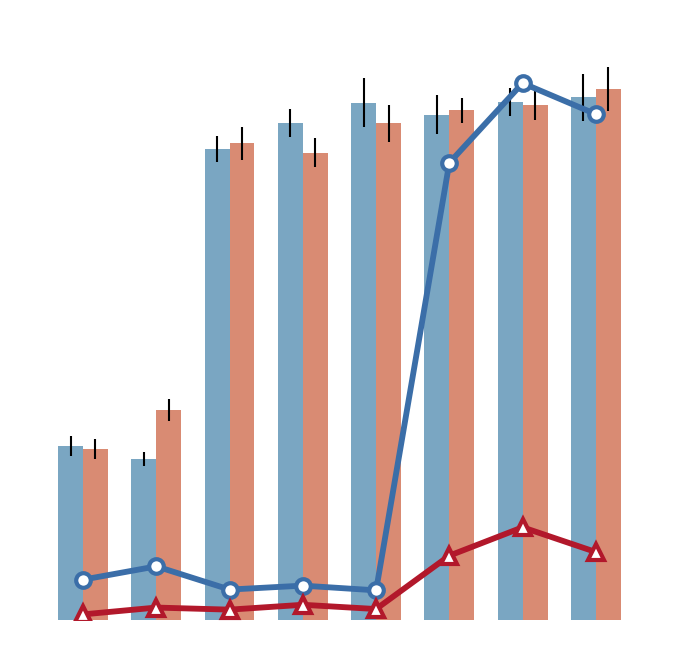

Saved:
./save_figs/fig3_d.svg


In [ ]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# =========================================================
# 1. File path
# =========================================================
excel_path = "../data/fig3_d.xlsx"
save_dir = "./save_figs"
os.makedirs(save_dir, exist_ok=True)

save_svg = os.path.join(save_dir, "fig3_d.svg")


# =========================================================
# 2. Read Excel
# =========================================================
raw = pd.read_excel(excel_path, header=None)

data_rows = raw.iloc[1:, :7].copy()
data_rows.columns = [
    "method",
    "k_mean", "k_std", "k_time",
    "h_mean", "h_std", "h_time"
]

data_rows = data_rows[data_rows["method"].notna()].reset_index(drop=True)

num_cols = ["k_mean", "k_std", "k_time", "h_mean", "h_std", "h_time"]
for col in num_cols:
    data_rows[col] = pd.to_numeric(data_rows[col], errors="coerce")

data_rows = data_rows.dropna(
    subset=["k_mean", "h_mean"],
    how="all"
).reset_index(drop=True)


# =========================================================
# 3. Plot settings
# =========================================================
methods = data_rows["method"].astype(str).tolist()
x = np.arange(len(methods))

bar_width = 0.34

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"

nature_rb_cmap = LinearSegmentedColormap.from_list(
    "nature_red_blue",
    [
        "#3B6EA8",  # muted blue
        "#7AA6C2",  # light blue
        "#E8E8E8",  # soft neutral
        "#D98B73",  # soft red-orange
        "#B2182B",  # deep red
    ],
)

blue_color = "#7AA6C2A9"
red_color = "#D98B73B3"

blue_line_color = "#3B6EA8"
red_line_color = "#B2182B"

# Error bar custom settings
ERRORBAR_LINEWIDTH = 0.5
ERRORBAR_CAPTHICK = 0.5
ERRORBAR_CAPSIZE = 0


# =========================================================
# 4. Create figure
# 6.6 cm × 4.35 cm
# =========================================================
fig, ax1 = plt.subplots(figsize=(5.24 / 2.54, 5 / 2.54), dpi=300)
ax2 = ax1.twinx()


# =========================================================
# 5. Bar plot
# =========================================================
ax1.bar(
    x - bar_width / 2,
    data_rows["k_mean"],
    yerr=data_rows["k_std"],
    width=bar_width,
    color=blue_color,
    edgecolor="none",
    linewidth=0,
    capsize=ERRORBAR_CAPSIZE,
    error_kw=dict(
        elinewidth=ERRORBAR_LINEWIDTH,
        capthick=ERRORBAR_CAPTHICK,
        ecolor='black',
    ),
    zorder=3
)

ax1.bar(
    x + bar_width / 2,
    data_rows["h_mean"],
    yerr=data_rows["h_std"],
    width=bar_width,
    color=red_color,
    edgecolor="none",
    linewidth=0,
    capsize=ERRORBAR_CAPSIZE,
    error_kw=dict(
        elinewidth=ERRORBAR_LINEWIDTH,
        capthick=ERRORBAR_CAPTHICK,
        ecolor='black',
    ),
    zorder=3
)


# =========================================================
# 6. Line plot
# =========================================================
ax2.plot(
    x,
    data_rows["k_time"],
    marker="o",
    markersize=3.5,
    linewidth=1.4,
    color=blue_line_color,
    markerfacecolor="white",
    markeredgewidth=1.0,
    zorder=4
)

ax2.plot(
    x,
    data_rows["h_time"],
    marker="^",
    markersize=4.0,
    linewidth=1.4,
    color=red_line_color,
    markerfacecolor="white",
    markeredgewidth=1.0,
    zorder=4
)


# =========================================================
# 7. Remove all axes, ticks, labels, legends
# =========================================================
ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_yticks([])

ax1.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("")
ax1.set_title("")

ax1.grid(False)
ax2.grid(False)

for spine in ax1.spines.values():
    spine.set_visible(False)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax1.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

ax2.tick_params(
    right=False,
    labelright=False
)

ax1.set_ylim(0.0, 0.95)

max_time = np.nanmax([
    data_rows["k_time"].max(),
    data_rows["h_time"].max()
])
ax2.set_ylim(0, max_time * 1.10)


# =========================================================
# 8. Save
# =========================================================
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(save_svg, format="svg", bbox_inches="tight", pad_inches=0)
plt.show()

print("Saved:")
print(save_svg)

[0.14046822742474915, 0.09197324414715718, 0.1806020066889632, 0.21906354515050167, 0.08193979933110368, 0.13043478260869565, 0.15551839464882944]


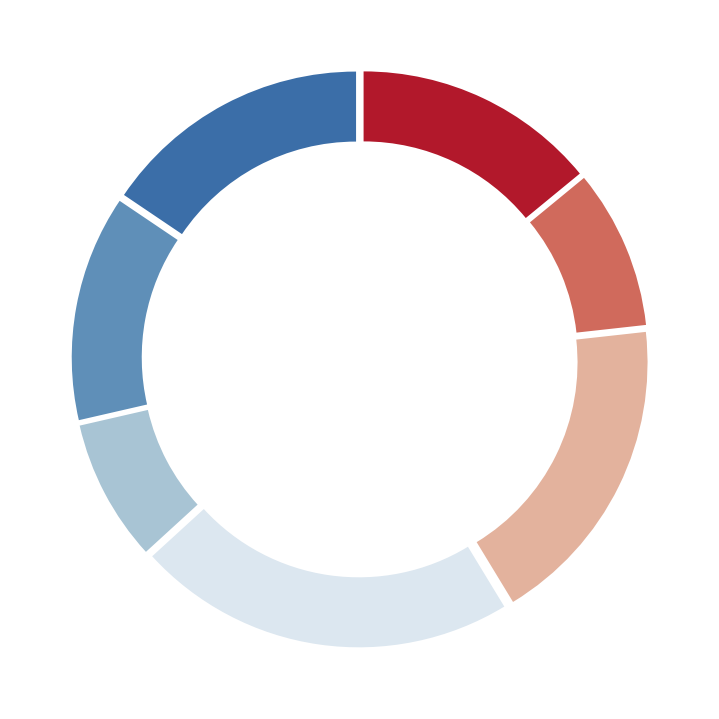

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# 输入数据
# =========================
counts = [84, 55, 108, 131, 49, 78, 93]
count_ratio = [i / sum(counts) for i in counts]
print(count_ratio)

colors = [
    "#B2182B",  # deep red
    "#D06A5C",  # muted red
    "#E3B29D",  # pale red-orange
    "#DCE7F0",  # blue-tinted neutral
    "#A8C4D4",  # pale blue
    "#5F8FB8",  # medium blue
    "#3B6EA8",  # muted blue
]

# =========================
# 画 donut
# =========================
fig, ax = plt.subplots(figsize=(7, 7))

# 设置透明背景
fig.patch.set_alpha(0)
ax.set_facecolor("none")

explode = [0.03] * len(counts)

wedges, texts = ax.pie(
    counts,
    colors=colors,
    startangle=90,
    explode=explode,
    counterclock=False,
    wedgeprops=dict(
        width=0.25,
        edgecolor="none"   # 不要白色边框
    )
)

ax.set(aspect="equal")
ax.axis("off")  # 去掉坐标轴

plt.tight_layout(pad=0)

plt.savefig(
    "./save_figs/fig3_c.svg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)

plt.show()

fig3_c_df = pd.DataFrame({
    "prototype": [f"P{i+1}" for i in range(len(counts))],
    "count": counts,
    "ratio": count_ratio,
    "color": colors,
})

fig3_c_df.to_csv(
    "./figs_data/fig3_c.csv",
    index=False,
)

In [4]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. Output
# ============================================================
OUT_DIR = "./prototype_radar_figs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

# ============================================================
# 1. Data
# ============================================================
prototype_records = {
    "P1": 17,
    "P2": 32,
    "P3": 69,
    "P4": 26,
    "P5": 34,
    "P6": 19,
    "P7": 30,
}

mechanism_data = {
    "P1": {
        "SEI/CEI formation": 15,
        "Solvation/desolvation": 12,
        "LiF/B-O interface": 12,
        "Thermal/corrosion stability": 12,
        "Polymer/gel strengthening": 11,
    },
    "P2": {
        "SEI/CEI formation": 26,
        "Lewis acid/anion receptor": 25,
        "LiF/B-O interface": 24,
        "Thermal/corrosion stability": 18,
        "Solvation/desolvation": 17,
    },
    "P3": {
        "SEI/CEI formation": 68,
        "LiF/B-O interface": 55,
        "Thermal/corrosion stability": 49,
        "HF/H2O scavenging": 39,
        "Polymer/gel strengthening": 37,
    },
    "P4": {
        "HF/H2O scavenging": 22,
        "Thermal/corrosion stability": 19,
        "SEI/CEI formation": 15,
        "LiF/B-O interface": 14,
        "Lewis acid/anion receptor": 9,
    },
    "P5": {
        "SEI/CEI formation": 26,
        "Thermal/corrosion stability": 25,
        "LiF/B-O interface": 22,
        "Lewis acid/anion receptor": 15,
        "HF/H2O scavenging": 13,
    },
    "P6": {
        "LiF/B-O interface": 17,
        "Lewis acid/anion receptor": 15,
        "SEI/CEI formation": 15,
        "HF/H2O scavenging": 14,
        "Thermal/corrosion stability": 11,
    },
    "P7": {
        "SEI/CEI formation": 28,
        "Lewis acid/anion receptor": 24,
        "Polymer/gel strengthening": 19,
        "Solvation/desolvation": 18,
        "LiF/B-O interface": 16,
    },
}

mechanisms = [
    "SEI/CEI formation",
    "LiF/B-O interface",
    "Lewis acid/anion receptor",
    "Solvation/desolvation",
    "HF/H2O scavenging",
    "Polymer/gel strengthening",
    "Thermal/corrosion stability",
]

prototypes = list(prototype_records.keys())

# ============================================================
# 2. Build frequency table
# ============================================================
count_df = pd.DataFrame(0, index=prototypes, columns=mechanisms, dtype=float)

for p, tags in mechanism_data.items():
    for m, v in tags.items():
        count_df.loc[p, m] = v

record_s = pd.Series(prototype_records)
freq_df = count_df.div(record_s, axis=0)

count_df.to_csv(os.path.join(OUT_DIR, "prototype_mechanism_counts.csv"))
freq_df.to_csv(os.path.join(OUT_DIR, "prototype_mechanism_frequency.csv"))

# ============================================================
# 3. Radar plot settings
# ============================================================
angles = np.linspace(0, 2 * np.pi, len(mechanisms), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

prototype_colors = {
    "P1": "#B2182B",
    "P2": "#D98B73",
    "P3": "#E7C1B0",
    "P4": "#C9DCEE",
    "P5": "#8FB3CB",
    "P6": "#5F8FB8",
    "P7": "#3B6EA8",
}

# ============================================================
# 4. Save one clean radar plot for each prototype
# No text, no tick labels, no title
# ============================================================
for p in prototypes:
    vals = freq_df.loc[p].values
    vals = np.concatenate([vals, [vals[0]]])

    fig, ax = plt.subplots(
        figsize=(2.2, 2.2),
        subplot_kw=dict(polar=True)
    )

    color = prototype_colors[p]

    ax.plot(
        angles,
        vals,
        color=color,
        linewidth=2.0
    )

    ax.fill(
        angles,
        vals,
        color=color,
        alpha=0.25
    )

    # 保留雷达图方向，但去掉所有文字
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # 保留网格，但去掉刻度数值
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels([])

    ax.set_ylim(0, 1.05)

    # 去掉标题
    ax.set_title("")

    # 网格样式
    ax.grid(True, linewidth=0.6, alpha=0.35)

    # 外圈边框
    ax.spines["polar"].set_linewidth(0.8)
    ax.spines["polar"].set_alpha(0.45)

    # 去掉刻度线
    ax.tick_params(
        axis="both",
        which="both",
        length=0,
        labelsize=0
    )

    plt.tight_layout(pad=0.05)

    plt.savefig(
        os.path.join(OUT_DIR, f"{p}_radar_profile_clean.svg"),
        format="svg",
        bbox_inches="tight",
        transparent=True
    )

    plt.savefig(
        os.path.join(OUT_DIR, f"{p}_radar_profile_clean.png"),
        dpi=600,
        bbox_inches="tight",
        transparent=True
    )

    plt.close()

print("Done. Clean separate radar plots are saved in:", OUT_DIR)

Done. Clean separate radar plots are saved in: ./prototype_radar_figs
